<div style="color:#3c4d5a; border-top:7px solid #42A5F5; border-bottom:7px solid #42A5F5; padding:8px; text-align:center; text-transform:uppercase">
  <h1>Streaming Adaptativo y Predicción de Reducción de Calidad mediante Machine Learning</h1>
</div>


Desarrollado por: Alexis Guamán y Cinthya Ramón


<div id="introduccion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>1. Introducción</h2> </div>


Las transmisiones en vivo realizadas mediante plataformas como YouTube, Twitch, Facebook Live y Kick dependen de una conexión estable a internet. En el streaming IRL, la señal suele enviarse mediante redes móviles, donde la velocidad de subida, la latencia, el jitter y la pérdida de paquetes pueden cambiar constantemente.

Cuando se utiliza una configuración fija de bitrate y resolución, una reducción en la capacidad de la red puede provocar pérdida de frames, congelamientos, disminución de calidad o interrupciones. Los sistemas tradicionales suelen reaccionar después de que el problema ya ha ocurrido.

Para solucionar este problema, se propone desarrollar un sistema autónomo de streaming adaptativo mediante Machine Learning. La señal será capturada desde un dispositivo móvil y enviada mediante VDO.Ninja hacia OBS Studio. OBS transmitirá mediante RTMP hacia un servidor con MediaMTX y FFmpeg, encargado de procesar y retransmitir el contenido hacia plataformas externas.

El sistema utilizará dos modelos supervisados. El modelo reactivo analizará las condiciones actuales de la red y recomendará uno de tres perfiles de transmisión: low, medium o high.

El modelo predictivo analizará las métricas registradas durante los últimos 10 o 15 minutos y determinará si el perfil actual podrá mantenerse durante los próximos 10 minutos o si será necesario reducir la calidad. Sus salidas serán maintain y downgrade_needed.

Las respuestas de ambos modelos serán procesadas por un agente autónomo. El agente podrá mantener, aumentar o reducir el perfil de transmisión, aplicar márgenes de seguridad, histéresis y tiempos mínimos entre cambios. Cuando el modelo predictivo detecte que será necesario reducir la calidad, el agente realizará el cambio antes de que se produzca una interrupción.

Además, el sistema contará con un mecanismo de respaldo. Cuando se pierda completamente la señal principal, el servidor reproducirá automáticamente un video previamente configurado. Cuando la señal se recupere y permanezca estable, se restaurará la transmisión en vivo.


<div id="fundamentos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>2. Fundamentos y Objetivo</h2> </div>


**Objetivo General:** Desarrollar un sistema autónomo de streaming adaptativo mediante Machine Learning que seleccione el perfil adecuado según las condiciones actuales y prediga anticipadamente cuándo será necesario reducir la calidad para disminuir pérdida de frames, congelamientos e interrupciones.

**Dataset Reactivo (RTR-NetzTest):** Proporciona observaciones actuales de calidad de red.

**Dataset Predictivo (Ghent 4G/LTE):** Proporciona trazas temporales reales de redes móviles. *Nota:* Este dataset registra throughput de descarga, lo cual no es igual a subida. Se utiliza como proxy temporal inicial. El modelo final deberá reentrenarse con métricas reales de subida que provendrán de VDO.Ninja, OBS Studio y MediaMTX. Este dataset solo permite desarrollar un prototipo académico.


<div id="entorno" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>3. Preparación del entorno</h2> </div>


Importación de librerías base, configuración de variables relativas y verificación de versiones. Se detecta dinámicamente la raíz del proyecto y se crean los directorios necesarios.


In [1]:
import os
import sys
import json
import zipfile
import datetime
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

print(f"Python version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
import sklearn
print(f"Scikit-learn version: {sklearn.__version__}")

# Detección de la raíz del proyecto
current_dir = Path.cwd()
if current_dir.name == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

print(f"Project root: {project_root}")

# Creación de carpetas necesarias
dirs_to_create = [
    "data/raw/reactive",
    "data/raw/predictive",
    "data/processed",
    "reports/figures",
    "models",
    "notebooks"
]

for d in dirs_to_create:
    (project_root / d).mkdir(parents=True, exist_ok=True)



Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Pandas version: 3.0.3
Numpy version: 2.4.6
Scikit-learn version: 1.9.0
Project root: C:\Users\kenny\OneDrive\Documents\STREAM-AI\Adaptive-Streaming-ai


<div id="config" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>4. Configuración general</h2> </div>


Variables centrales del proyecto, como ventanas de tiempo y márgenes de seguridad. Aclaramos que las velocidades (bitrates) son valores iniciales del proyecto y **no** estándares universales.


In [2]:
RANDOM_STATE = 42
SAFETY_MARGIN = 1.35
LOOKBACK_SECONDS = 120
HORIZON_SECONDS = 180
WINDOW_STEP_SECONDS = 10

PROFILE_BITRATE_KBPS = {
    "low": 1000,
    "medium": 2500,
    "high": 5000
}

PROFILE_REQUIRED_MBPS = {
    k: (v * SAFETY_MARGIN) / 1000 for k, v in PROFILE_BITRATE_KBPS.items()
}

print("Profile Required Mbps:")
for k, v in PROFILE_REQUIRED_MBPS.items():
    print(f"  {k}: {v:.3f} Mbps")



Profile Required Mbps:
  low: 1.350 Mbps
  medium: 3.375 Mbps
  high: 6.750 Mbps


<div id="descarga-rtr" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>5. Descarga y verificación de RTR-NetzTest</h2> </div>


Procedemos a descargar el archivo oficial de las últimas 48 horas desde la interfaz Open Data de RTR-NetzTest. Este tamaño asegura ser manejable (>20,000 registros).


In [3]:
# Configuración de RTR-NetzTest
rtr_url = "https://www.netztest.at/RMBTStatisticServer/export/netztest-opendata_hours-048.zip"
rtr_zip_path = project_root / "data/raw/reactive/netztest_sample.zip"
rtr_extract_dir = project_root / "data/raw/reactive"

rtr_metadata = {
    "url_oficial": rtr_url,
    "fecha_descarga": None,
    "parametros": "ultimas_48_horas",
    "archivo_guardado": rtr_zip_path.name,
    "tamaño_archivo_bytes": 0,
    "estado": "pendiente"
}

if not rtr_zip_path.exists():
    print("Descargando RTR-NetzTest...")
    try:
        response = requests.get(rtr_url, timeout=30)
        response.raise_for_status()
        with open(rtr_zip_path, 'wb') as f:
            f.write(response.content)
        rtr_metadata["fecha_descarga"] = datetime.datetime.utcnow().isoformat()
        rtr_metadata["tamaño_archivo_bytes"] = rtr_zip_path.stat().st_size
        rtr_metadata["estado"] = "completado"
        print("Descarga exitosa.")
    except Exception as e:
        print(f"Error en la descarga: {e}")
        rtr_metadata["estado"] = "error"
        raise RuntimeError("Fallo la descarga de RTR-NetzTest. Deteniendo.")
else:
    print("El archivo RTR-NetzTest ya existe.")
    rtr_metadata["fecha_descarga"] = datetime.datetime.fromtimestamp(rtr_zip_path.stat().st_ctime).isoformat()
    rtr_metadata["tamaño_archivo_bytes"] = rtr_zip_path.stat().st_size
    rtr_metadata["estado"] = "previamente_descargado"

# Descomprimir (ignorar errores si ya esta)
with zipfile.ZipFile(rtr_zip_path, 'r') as zip_ref:
    zip_ref.extractall(rtr_extract_dir)

csv_files = list(rtr_extract_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError("No se encontró el CSV extraído.")
rtr_csv_path = csv_files[0]



El archivo RTR-NetzTest ya existe.


<div id="exploracion-rtr" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>6. Análisis exploratorio de RTR-NetzTest</h2> </div>


Verificación de columnas, tipos, nulos y visualización inicial.


In [4]:
df_rtr_raw = pd.read_csv(rtr_csv_path, sep=';', low_memory=False)
if len(df_rtr_raw.columns) == 1:
    df_rtr_raw = pd.read_csv(rtr_csv_path, sep=',', low_memory=False)

print(f"Dimensiones iniciales: {df_rtr_raw.shape}")
print("\nColumnas reales (Muestra):", list(df_rtr_raw.columns)[:15])

expected_rtr_cols = ['time_utc', 'upload_kbit', 'download_kbit', 'ping_ms', 'network_type', 'cat_technology', 'signal_strength', 'implausible']
print("\nVerificación de variables solicitadas:")
for c in expected_rtr_cols:
    print(f" - {c}: {c in df_rtr_raw.columns}")

print("\nNulos en variables de interes (si existen):")
for c in expected_rtr_cols:
    if c in df_rtr_raw.columns:
        print(f"{c}: {df_rtr_raw[c].isnull().sum()} nulos")

print("\nDuplicados totales en el dataset:", df_rtr_raw.duplicated().sum())

if 'network_type' in df_rtr_raw.columns:
    print("\nValores únicos de network_type:")
    print(df_rtr_raw['network_type'].value_counts().head(5))

display(df_rtr_raw.head())
display(df_rtr_raw.tail())



Dimensiones iniciales: (26686, 52)

Columnas reales (Muestra): ['open_uuid', 'open_test_uuid', 'time_utc', 'cat_technology', 'network_type', 'lat', 'long', 'loc_src', 'loc_accuracy', 'gkz', 'zip_code', 'country_location', 'download_kbit', 'upload_kbit', 'ping_ms']

Verificación de variables solicitadas:
 - time_utc: True
 - upload_kbit: True
 - download_kbit: True
 - ping_ms: True
 - network_type: True
 - cat_technology: True
 - signal_strength: True
 - implausible: True

Nulos en variables de interes (si existen):
time_utc: 0 nulos
upload_kbit: 0 nulos
download_kbit: 0 nulos
ping_ms: 0 nulos
network_type: 0 nulos
cat_technology: 0 nulos
signal_strength: 21022 nulos
implausible: 0 nulos

Duplicados totales en el dataset: 0

Valores únicos de network_type:
network_type
LAN         12464
WLAN         9444
NR NSA       1634
LTE          1400
Ethernet      797
Name: count, dtype: int64


,open_uuid,open_test_uuid,time_utc,cat_technology,network_type,lat,long,loc_src,loc_accuracy,gkz,...,link_id,link_name,link_distance,edge_id,link_frc,dtm_level,signal_classification,temperature,atraster100,atraster250
0,P693b01b7-5ebb-4a24-8c57-e788ac2c4024,Od1656d4e-9bc0-434b-b522-264442b7ff71,2026-07-12 02:44:07,WLAN,WLAN,47.503206,9.750141,gps,0.5,80207.0,...,NaN,NaN,NaN,NaN,NaN,405.0,NaN,29.9,100mN27099E43021,250mN270975E430200
1,P246ae4c8-ffbe-448a-ad40-9164c1fb8ee3,O74ed62b1-9125-41a1-acc6-6a03b2b3ac19,2026-07-12 02:44:11,LAN,LAN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P0c75977c-e933-4b7f-aa27-68e334a85925,Oada3060f-9547-47af-98fe-17943b324ebb,2026-07-12 02:45:44,4G,LTE,4.639388,-75.569118,NaN,3.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Pfc9eb540-ce94-40a8-9604-460c54f627f6,O663bf07b-9d09-4146-8506-afc5a2ff549f,2026-07-12 02:45:58,Ethernet,Ethernet,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,P81584a49-c0f3-4009-a717-3ec882e4191f,Of4ecf94d-bc34-4ce1-bdd2-f48eb4a9843b,2026-07-12 02:46:40,LAN,LAN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,open_uuid,open_test_uuid,time_utc,cat_technology,network_type,lat,long,loc_src,loc_accuracy,gkz,...,link_id,link_name,link_distance,edge_id,link_frc,dtm_level,signal_classification,temperature,atraster100,atraster250
26681,Pac8c5904-ea5c-4900-a942-322b0d0434a3,O97c1eda1-70ee-42e8-ae63-be4f44b810f0,2026-07-14 02:41:29,WLAN,WLAN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26682,Pd4f1c63a-256d-4184-8ad4-39d8058c9c35,Obbb6b135-5095-4e21-961e-9b7e23c0ca4c,2026-07-14 02:41:53,Ethernet,Ethernet,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26683,Pc9c4e648-f9f5-447c-9772-f4ba7150901a,O1e0a989f-34e1-4752-8c0d-9ade93f1b8b6,2026-07-14 02:42:09,WLAN,WLAN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.4,NaN,NaN
26684,P4f48a7b0-dcc9-458a-bf37-96ce577cb410,Oa5c24f8f-cebf-49c5-9f1f-fe4f258c3ddd,2026-07-14 02:42:34,LAN,LAN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26685,P7be7166f-cf1a-4df1-8a51-a84056884f09,O7012d026-243f-4dfa-ba7d-826b11f3b0fa,2026-07-14 02:42:54,Ethernet,Ethernet,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div id="limpieza-rtr" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>7. Limpieza de RTR-NetzTest</h2> </div>


Normalización de columnas, conversiones de unidades y eliminación de datos no válidos (implausibles, negativos, etc.).


In [5]:
df_rtr = df_rtr_raw.copy()

# Filtrar columnas requeridas que existen
cols_to_keep = [c for c in expected_rtr_cols if c in df_rtr.columns] + ['open_test_uuid']
df_rtr = df_rtr[list(set(cols_to_keep))]

# Normalización snake_case (aunque ya vienen asi en este dataset, aseguramos)
df_rtr.columns = [c.lower().replace(' ', '_') for c in df_rtr.columns]

# Transformaciones
if 'upload_kbit' in df_rtr.columns:
    df_rtr['upload_mbps'] = df_rtr['upload_kbit'] / 1000.0
    
if 'download_kbit' in df_rtr.columns:
    df_rtr['download_mbps'] = df_rtr['download_kbit'] / 1000.0
    
if 'time_utc' in df_rtr.columns:
    df_rtr['time_utc'] = pd.to_datetime(df_rtr['time_utc'], errors='coerce', utc=True)
    
if 'ping_ms' in df_rtr.columns:
    df_rtr['ping_ms'] = pd.to_numeric(df_rtr['ping_ms'], errors='coerce')
    
if 'network_type' in df_rtr.columns:
    df_rtr['network_type'] = df_rtr['network_type'].astype(str)
    
if 'cat_technology' in df_rtr.columns:
    df_rtr['cat_technology'] = df_rtr['cat_technology'].astype(str)

initial_len = len(df_rtr)

# Implausible
if 'implausible' in df_rtr.columns:
    df_rtr = df_rtr[df_rtr['implausible'] != True]
    print(f"Borrados por implausible: {initial_len - len(df_rtr)}")
    
# Limpieza justificada
if 'upload_mbps' in df_rtr.columns:
    df_rtr = df_rtr.dropna(subset=['upload_mbps'])
    df_rtr = df_rtr[df_rtr['upload_mbps'] >= 0]
    
if 'download_mbps' in df_rtr.columns:
    df_rtr = df_rtr[df_rtr['download_mbps'] >= 0]
    
if 'ping_ms' in df_rtr.columns:
    df_rtr = df_rtr[df_rtr['ping_ms'] >= 0]
    
if 'time_utc' in df_rtr.columns:
    df_rtr = df_rtr.dropna(subset=['time_utc'])

# Duplicados
df_rtr = df_rtr.drop_duplicates()

print(f"Total registros despues de limpieza: {len(df_rtr)}")



Borrados por implausible: 0
Total registros despues de limpieza: 26686


<div id="prep-reactivo" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>8. Preparación del dataset reactivo</h2> </div>


Generación de pseudoetiqueta (`recommended_profile`) mediante la función `asignar_perfil_recomendado` y división cronológica del dataset (70% train, 15% validation, 15% test).



Distribución de recommended_profile:
recommended_profile
high      21590
low        2882
medium     2214
Name: count, dtype: int64

Porcentajes:
recommended_profile
high      80.903845
low       10.799670
medium     8.296485
Name: proportion, dtype: float64


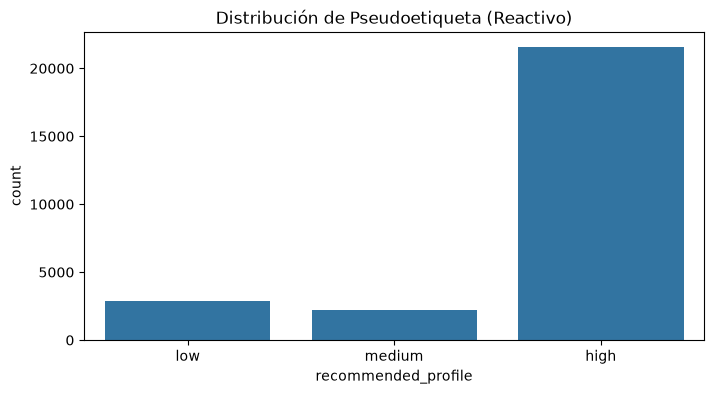


Verificación de particiones:
recommended_profile   high   low  medium
split                                   
test                  3326   397     279
train                15018  2056    1606
validation            3246   429     329

Guardando dataset reactivo con 26686 registros.


In [6]:
def asignar_perfil_recomendado(upload_mbps, ping_ms=None):
    # Regla base
    if upload_mbps >= PROFILE_REQUIRED_MBPS["high"]:
        prof = "high"
    elif upload_mbps >= PROFILE_REQUIRED_MBPS["medium"]:
        prof = "medium"
    else:
        prof = "low"
        
    # Penalizacion por latencia
    if pd.notnull(ping_ms):
        if ping_ms > 300:
            prof = "low"
        elif ping_ms > 150:
            if prof == "high":
                prof = "medium"
            elif prof == "medium":
                prof = "low"
    
    return prof

if 'upload_mbps' in df_rtr.columns:
    ping_series = df_rtr['ping_ms'] if 'ping_ms' in df_rtr.columns else [None]*len(df_rtr)
    df_rtr['recommended_profile'] = [asignar_perfil_recomendado(u, p) for u, p in zip(df_rtr['upload_mbps'], ping_series)]

print("\nDistribución de recommended_profile:")
profile_counts = df_rtr['recommended_profile'].value_counts()
print(profile_counts)
print("\nPorcentajes:")
print(df_rtr['recommended_profile'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8,4))
sns.countplot(data=df_rtr, x='recommended_profile', order=['low', 'medium', 'high'])
plt.title("Distribución de Pseudoetiqueta (Reactivo)")
plt.savefig(project_root / 'reports/figures/reactivo_target_dist.png')
plt.show()

# División cronológica
df_rtr = df_rtr.sort_values('time_utc').reset_index(drop=True)
n = len(df_rtr)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

df_rtr['split'] = 'test'
df_rtr.loc[:train_end, 'split'] = 'train'
df_rtr.loc[train_end:val_end, 'split'] = 'validation'

print("\nVerificación de particiones:")
print(pd.crosstab(df_rtr['split'], df_rtr['recommended_profile']))

final_cols_reactivo = ['open_test_uuid', 'time_utc', 'upload_mbps', 'download_mbps', 'ping_ms', 'network_type', 'cat_technology', 'signal_strength', 'recommended_profile', 'split']
final_cols_reactivo = [c for c in final_cols_reactivo if c in df_rtr.columns]
df_reactivo = df_rtr[final_cols_reactivo]

print(f"\nGuardando dataset reactivo con {len(df_reactivo)} registros.")



<div id="descarga-ghent" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>9. Descarga y verificación de Ghent 4G/LTE</h2> </div>


Descargamos el dataset oficial logs_all.zip, lo descomprimimos y combinamos todas las sesiones (archivos report_*.log) asignando `session_id` y `transport_type`.


In [7]:
ghent_url = "http://users.ugent.be/~jvdrhoof/dataset-4g/logs/logs_all.zip"
ghent_zip_path = project_root / "data/raw/predictive/logs_all.zip"
ghent_extract_dir = project_root / "data/raw/predictive/logs"
ghent_extract_dir.mkdir(parents=True, exist_ok=True)

if not ghent_zip_path.exists() or ghent_zip_path.stat().st_size < 1000:
    print("Descargando Ghent 4G/LTE...")
    try:
        response = requests.get(ghent_url, timeout=30)
        response.raise_for_status()
        with open(ghent_zip_path, 'wb') as f:
            f.write(response.content)
        print("Descarga exitosa.")
    except Exception as e:
        print(f"Error en la descarga: {e}")
        raise RuntimeError("Fallo la descarga de Ghent.")

with zipfile.ZipFile(ghent_zip_path, 'r') as zip_ref:
    zip_ref.extractall(ghent_extract_dir)

ghent_files = list(ghent_extract_dir.glob("report_*.log"))
print(f"Cantidad de archivos: {len(ghent_files)}")

ghent_dfs = []
for f in ghent_files:
    session_id = f.stem
    df_temp = pd.read_csv(f, sep=r'\s+', header=None, on_bad_lines='skip')
    # Verificacion de 6 columnas
    if df_temp.shape[1] == 6:
        df_temp.columns = ["timestamp_ms", "elapsed_ms", "latitude", "longitude", "bytes_received", "interval_ms"]
        df_temp['session_id'] = session_id
        
        if 'bicycle' in session_id:
            tt = 'bicycle'
        elif 'car' in session_id:
            tt = 'car'
        elif 'foot' in session_id:
            tt = 'foot'
        elif 'train' in session_id:
            tt = 'train'
        elif 'tram' in session_id:
            tt = 'tram'
        elif 'bus' in session_id:
            tt = 'bus'
        else:
            tt = 'unknown'
        df_temp['transport_type'] = tt
        
        ghent_dfs.append(df_temp)

df_ghent_raw = pd.concat(ghent_dfs, ignore_index=True)
print(f"Total registros cargados de todas las sesiones: {len(df_ghent_raw)}")



Cantidad de archivos: 40
Total registros cargados de todas las sesiones: 18036


<div id="exploracion-ghent" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>10. Análisis exploratorio de Ghent</h2> </div>


Exploración básica para comprobar tipos y columnas.


In [8]:
display(df_ghent_raw.head())
print("\nTipos de datos originales:")
print(df_ghent_raw.dtypes)



,timestamp_ms,elapsed_ms,latitude,longitude,bytes_received,interval_ms,session_id,transport_type
0,1452002003586,840,51.036403,3.735912,1766452,840,report_bicycle_0001,bicycle
1,1452002004586,1840,51.036403,3.735912,2810698,1000,report_bicycle_0001,bicycle
2,1452002005586,2840,51.036403,3.735912,3227852,1000,report_bicycle_0001,bicycle
3,1452002006586,3840,51.036403,3.735912,4132442,1000,report_bicycle_0001,bicycle
4,1452002007586,4840,51.036403,3.735912,2942908,1000,report_bicycle_0001,bicycle



Tipos de datos originales:
timestamp_ms        int64
elapsed_ms          int64
latitude          float64
longitude         float64
bytes_received      int64
interval_ms         int64
session_id            str
transport_type        str
dtype: object


<div id="limpieza-ghent" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>11. Limpieza y construcción de sesiones</h2> </div>


Convertimos a numérico, eliminamos filas inconsistentes, calculamos `throughput_mbps` y visualizamos resultados.


Registros eliminados en Ghent por reglas de consistencia: 0
Total registros limpios de Ghent: 18036

Estadísticas globales de throughput (Mbps):
count    18036.000000
mean        30.220083
std         16.681825
min          0.000000
10%          9.185297
25%         18.033499
50%         28.777329
75%         40.773784
90%         54.023809
max        110.970592
Name: throughput_mbps, dtype: float64

Top 5 sesiones por duración:


,session_id,duracion_sec,registros,freq_media,tp_mean,transport_type
4,report_bus_0003,762.668,758,1006.158311,19.693080,bus
33,report_tram_0002,658.195,659,998.778452,14.053387,tram
1,report_bicycle_0002,657.106,658,998.641337,25.441104,bicycle
22,report_foot_0002,618.287,619,998.848142,17.542478,foot
2,report_bus_0001,606.726,607,999.548600,27.601533,bus


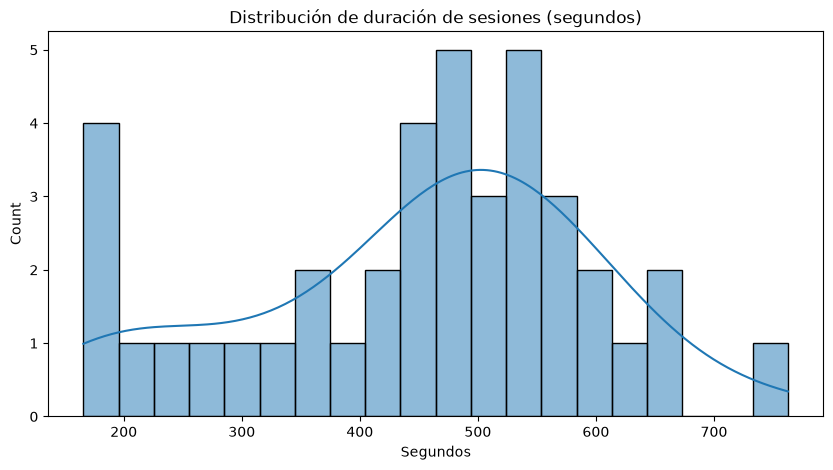

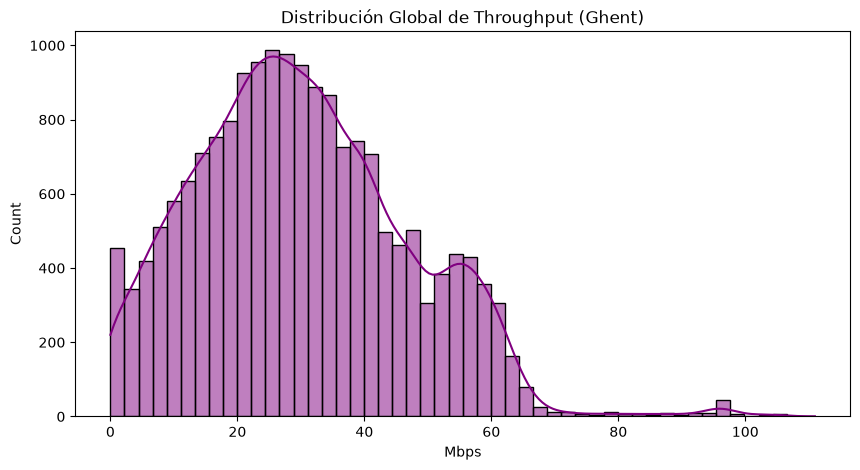

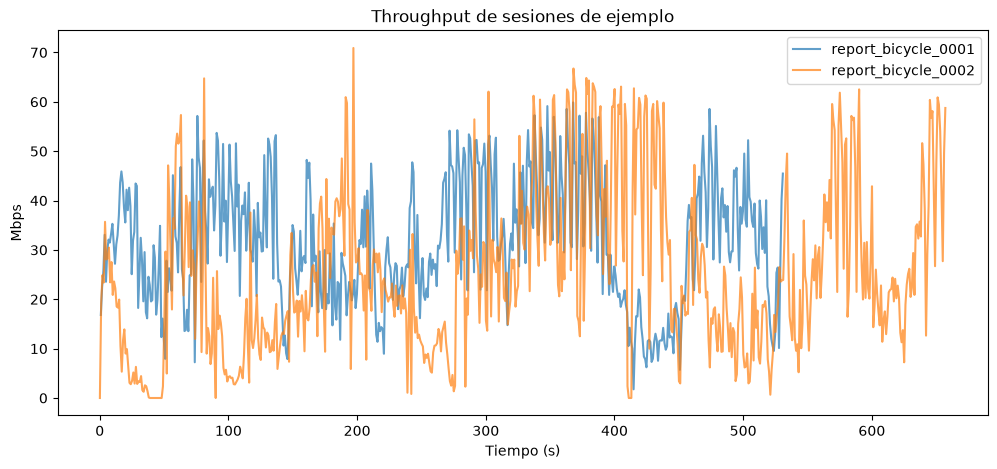

In [9]:
df_ghent = df_ghent_raw.copy()

num_cols = ["timestamp_ms", "elapsed_ms", "latitude", "longitude", "bytes_received", "interval_ms"]
for c in num_cols:
    df_ghent[c] = pd.to_numeric(df_ghent[c], errors='coerce')

# Eliminar nulos generados por la conversion
df_ghent = df_ghent.dropna(subset=num_cols + ['session_id'])

# Reglas de limpieza
initial_ghent = len(df_ghent)
df_ghent = df_ghent[df_ghent['interval_ms'] > 0]
df_ghent = df_ghent[df_ghent['bytes_received'] >= 0]
df_ghent = df_ghent[df_ghent['elapsed_ms'] >= 0]

print(f"Registros eliminados en Ghent por reglas de consistencia: {initial_ghent - len(df_ghent)}")

# Calculo de throughput
# bytes_received * 8 / (interval_ms / 1000) / 1_000_000
df_ghent['throughput_mbps'] = (df_ghent['bytes_received'] * 8) / (df_ghent['interval_ms'] / 1000) / 1000000

# Timestamp a datetime
# Algunos timestamps en este dataset pueden ser erroneos, los que sean invalidos quedaran como NaT
df_ghent['timestamp_utc'] = pd.to_datetime(df_ghent['timestamp_ms'], unit='ms', errors='coerce', utc=True)

# Ordenamiento por sesion y tiempo
df_ghent = df_ghent.sort_values(['session_id', 'elapsed_ms']).reset_index(drop=True)

print(f"Total registros limpios de Ghent: {len(df_ghent)}")

# Analisis global
print("\nEstadísticas globales de throughput (Mbps):")
print(df_ghent['throughput_mbps'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

# Duracion de sesiones
session_stats = df_ghent.groupby('session_id').agg(
    duracion_sec=('elapsed_ms', lambda x: x.max() / 1000),
    registros=('elapsed_ms', 'count'),
    freq_media=('interval_ms', 'mean'),
    tp_mean=('throughput_mbps', 'mean'),
    transport_type=('transport_type', 'first')
).reset_index()

print("\nTop 5 sesiones por duración:")
display(session_stats.sort_values('duracion_sec', ascending=False).head())

plt.figure(figsize=(10,5))
sns.histplot(session_stats['duracion_sec'], bins=20, kde=True)
plt.title("Distribución de duración de sesiones (segundos)")
plt.xlabel("Segundos")
plt.savefig(project_root / 'reports/figures/ghent_session_duration.png')
plt.show()

# Distribucion global throughput
plt.figure(figsize=(10,5))
sns.histplot(df_ghent['throughput_mbps'], bins=50, kde=True, color='purple')
plt.title("Distribución Global de Throughput (Ghent)")
plt.xlabel("Mbps")
plt.savefig(project_root / 'reports/figures/ghent_throughput_dist.png')
plt.show()

# Graficar un par de sesiones
sample_sessions = session_stats['session_id'].head(2).tolist()
plt.figure(figsize=(12,5))
for s in sample_sessions:
    temp = df_ghent[df_ghent['session_id'] == s]
    plt.plot(temp['elapsed_ms']/1000, temp['throughput_mbps'], label=s, alpha=0.7)
plt.title("Throughput de sesiones de ejemplo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Mbps")
plt.legend()
plt.savefig(project_root / 'reports/figures/ghent_sample_sessions.png')
plt.show()



<div id="ventanas" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>12. Creación de ventanas temporales</h2> </div>


Iteramos sobre cada sesión que cumpla la duración mínima (120s historial + 180s horizonte) avanzando en pasos de 10s. Calculamos métricas estadísticas sobre el historial y establecemos el target futuro.


In [10]:
min_duration_required = LOOKBACK_SECONDS + HORIZON_SECONDS
valid_sessions = session_stats[session_stats['duracion_sec'] >= min_duration_required]['session_id'].tolist()
excluded_sessions = session_stats[session_stats['duracion_sec'] < min_duration_required]['session_id'].tolist()

print(f"Sesiones válidas: {len(valid_sessions)}")
print(f"Sesiones excluidas por duración insuficiente: {len(excluded_sessions)}")
print("Ejemplo excluidas:", excluded_sessions[:5])

# Metadatos para exportar despues
meta_total_sessions = len(session_stats)
meta_excluded_sessions = len(excluded_sessions)

windows_data = []

# Calcular pendiente simple
def calc_slope(x, y):
    if len(x) < 2: return 0
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    num = np.sum((x - x_mean) * (y - y_mean))
    den = np.sum((x - x_mean)**2)
    return num / den if den != 0 else 0

for session in valid_sessions:
    df_s = df_ghent[df_ghent['session_id'] == session]
    # Determinar la frecuencia mediana de esta sesion (en ms)
    freq_ms = df_s['interval_ms'].median()
    if pd.isna(freq_ms) or freq_ms == 0:
        freq_ms = 1000
    
    expected_hist_count = (LOOKBACK_SECONDS * 1000) / freq_ms
    expected_fut_count = (HORIZON_SECONDS * 1000) / freq_ms
    
    max_time = df_s['elapsed_ms'].max()
    tt = df_s['transport_type'].iloc[0]
    
    # Crear ventanas con paso
    for w_end_sec in range(LOOKBACK_SECONDS, int(max_time/1000) - HORIZON_SECONDS, WINDOW_STEP_SECONDS):
        w_end_ms = w_end_sec * 1000
        w_start_ms = w_end_ms - (LOOKBACK_SECONDS * 1000)
        f_end_ms = w_end_ms + (HORIZON_SECONDS * 1000)
        
        hist = df_s[(df_s['elapsed_ms'] > w_start_ms) & (df_s['elapsed_ms'] <= w_end_ms)]
        fut = df_s[(df_s['elapsed_ms'] > w_end_ms) & (df_s['elapsed_ms'] <= f_end_ms)]
        
        # Check cobertura 80%
        if len(hist) >= 0.8 * expected_hist_count and len(fut) >= 0.8 * expected_fut_count:
            hist_tp = hist['throughput_mbps']
            fut_tp = fut['throughput_mbps']
            
            # Variables de historial
            mean_tp = hist_tp.mean()
            median_tp = hist_tp.median()
            min_tp = hist_tp.min()
            max_tp = hist_tp.max()
            std_tp = hist_tp.std()
            p10_tp = hist_tp.quantile(0.1)
            p25_tp = hist_tp.quantile(0.25)
            first_tp = hist_tp.iloc[0]
            last_tp = hist_tp.iloc[-1]
            change_tp = last_tp - first_tp
            slope_tp = calc_slope(hist['elapsed_ms'].values, hist_tp.values)
            cv_tp = std_tp / mean_tp if mean_tp > 0 else 0
            
            prop_low = (hist_tp < PROFILE_REQUIRED_MBPS['low']).mean()
            prop_med = (hist_tp < PROFILE_REQUIRED_MBPS['medium']).mean()
            prop_high = (hist_tp < PROFILE_REQUIRED_MBPS['high']).mean()
            
            # current_profile
            if p10_tp >= PROFILE_REQUIRED_MBPS['high']: curr_prof = 2
            elif p10_tp >= PROFILE_REQUIRED_MBPS['medium']: curr_prof = 1
            else: curr_prof = 0
            
            # Variables de futuro (no usar como input!)
            f_mean = fut_tp.mean()
            f_min = fut_tp.min()
            f_p10 = fut_tp.quantile(0.1)
            
            if f_p10 >= PROFILE_REQUIRED_MBPS['high']: f_prof = 2
            elif f_p10 >= PROFILE_REQUIRED_MBPS['medium']: f_prof = 1
            else: f_prof = 0
            
            f_below_low = 1 if f_p10 < PROFILE_REQUIRED_MBPS['low'] else 0
            
            # Target
            downgrade_needed = 1 if f_prof < curr_prof else 0
            
            windows_data.append({
                'session_id': session,
                'window_end_elapsed_seconds': w_end_sec,
                'transport_type': tt,
                'throughput_mean': mean_tp,
                'throughput_median': median_tp,
                'throughput_min': min_tp,
                'throughput_max': max_tp,
                'throughput_std': std_tp,
                'throughput_p10': p10_tp,
                'throughput_p25': p25_tp,
                'throughput_first': first_tp,
                'throughput_last': last_tp,
                'throughput_change': change_tp,
                'throughput_slope': slope_tp,
                'throughput_coefficient_variation': cv_tp,
                'measurements_count': len(hist),
                'lookback_duration_seconds': LOOKBACK_SECONDS,
                'proportion_below_low': prop_low,
                'proportion_below_medium': prop_med,
                'proportion_below_high': prop_high,
                'current_profile': curr_prof,
                'required_capacity_mbps': PROFILE_REQUIRED_MBPS['high'], # Placeholder global
                'future_throughput_mean': f_mean,
                'future_throughput_min': f_min,
                'future_throughput_p10': f_p10,
                'future_profile': f_prof,
                'future_below_low': f_below_low,
                'downgrade_needed': downgrade_needed
            })

df_windows = pd.DataFrame(windows_data)
print(f"Total ventanas creadas: {len(df_windows)}")



Sesiones válidas: 32
Sesiones excluidas por duración insuficiente: 8
Ejemplo excluidas: ['report_bus_0004', 'report_bus_0011', 'report_car_0007', 'report_car_0008', 'report_foot_0004']


Total ventanas creadas: 686


<div id="prep-predictivo" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>13. Preparación del dataset predictivo (Variables y Target)</h2> </div>


Verificación de la prevención de fuga temporal. Definimos qué columnas son predictivas y cuáles son del futuro o metadatos.


In [11]:
PREDICTIVE_FEATURE_COLUMNS = [
    'throughput_mean', 'throughput_median', 'throughput_min', 'throughput_max', 
    'throughput_std', 'throughput_p10', 'throughput_p25', 'throughput_first', 
    'throughput_last', 'throughput_change', 'throughput_slope', 
    'throughput_coefficient_variation', 'measurements_count', 
    'lookback_duration_seconds', 'proportion_below_low', 
    'proportion_below_medium', 'proportion_below_high', 
    'transport_type', 'current_profile', 'required_capacity_mbps'
]

FUTURE_ONLY_COLUMNS = [
    'future_throughput_mean', 'future_throughput_min', 
    'future_throughput_p10', 'future_profile', 'future_below_low', 
    'downgrade_needed', 'split'
]

# Validacion automatica de fuga
intersection = set(PREDICTIVE_FEATURE_COLUMNS).intersection(set(FUTURE_ONLY_COLUMNS))
assert len(intersection) == 0, f"FUGA TEMPORAL DETECTADA en columnas: {intersection}"
print("Validación de fuga temporal (Data Leakage) superada.")

print("\nDistribución de downgrade_needed:")
print(df_windows['downgrade_needed'].value_counts())
print("\nDistribución futura crítica (future_below_low):")
print(df_windows['future_below_low'].value_counts())



Validación de fuga temporal (Data Leakage) superada.

Distribución de downgrade_needed:
downgrade_needed
0    583
1    103
Name: count, dtype: int64

Distribución futura crítica (future_below_low):
future_below_low
0    649
1     37
Name: count, dtype: int64


<div id="split-predictivo" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>14. División del dataset predictivo</h2> </div>


Se divide el dataset asegurando que las **sesiones no se mezclen** entre Train/Val/Test.


In [12]:
# Obtener las sesiones unicas que realmente generaron ventanas
unique_sessions = df_windows['session_id'].unique()

# Determinacion de semillas para encontrar una division con ambas clases
# En un entorno real se usaria StratifiedGroupKFold, pero por simplicidad usaremos train_test_split sobre los session_ids
found_valid_split = False
best_seed = RANDOM_STATE

for seed in range(RANDOM_STATE, RANDOM_STATE + 100):
    train_sess, temp_sess = train_test_split(unique_sessions, test_size=0.3, random_state=seed)
    val_sess, test_sess = train_test_split(temp_sess, test_size=0.5, random_state=seed)
    
    t_df = df_windows[df_windows['session_id'].isin(train_sess)]
    v_df = df_windows[df_windows['session_id'].isin(val_sess)]
    te_df = df_windows[df_windows['session_id'].isin(test_sess)]
    
    # Chequear que todas las particiones tengan las 2 clases
    if (len(t_df['downgrade_needed'].unique()) == 2 and 
        len(v_df['downgrade_needed'].unique()) == 2 and 
        len(te_df['downgrade_needed'].unique()) == 2):
        found_valid_split = True
        best_seed = seed
        break

if not found_valid_split:
    print("Limitación: No se encontró una semilla que garantice todas las clases en todos los splits. Se usará la semilla por defecto.")
    train_sess, temp_sess = train_test_split(unique_sessions, test_size=0.3, random_state=RANDOM_STATE)
    val_sess, test_sess = train_test_split(temp_sess, test_size=0.5, random_state=RANDOM_STATE)
else:
    print(f"División válida encontrada con semilla {best_seed}")

df_windows['split'] = 'unknown'
df_windows.loc[df_windows['session_id'].isin(train_sess), 'split'] = 'train'
df_windows.loc[df_windows['session_id'].isin(val_sess), 'split'] = 'validation'
df_windows.loc[df_windows['session_id'].isin(test_sess), 'split'] = 'test'

print("\nDistribución por split y target:")
print(pd.crosstab(df_windows['split'], df_windows['downgrade_needed']))

# Validacion estricta
s_train = set(train_sess)
s_val = set(val_sess)
s_test = set(test_sess)
assert len(s_train.intersection(s_val)) == 0, "Cruce Train-Val"
assert len(s_train.intersection(s_test)) == 0, "Cruce Train-Test"
assert len(s_val.intersection(s_test)) == 0, "Cruce Val-Test"
print("\nValidación de cruce de sesiones superada.")

df_predictivo = df_windows.copy()
print(f"\nGuardando dataset predictivo con {len(df_predictivo)} registros.")



División válida encontrada con semilla 42

Distribución por split y target:
downgrade_needed    0   1
split                    
test               93   6
train             417  95
validation         73   2

Validación de cruce de sesiones superada.

Guardando dataset predictivo con 686 registros.


<div id="diccionario" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>15. Diccionario de variables</h2> </div>


Generación del archivo `data_dictionary.csv` con la descripción de todas las variables.


In [13]:
dictionary_data = [
    # Reactivo
    {"dataset": "reactivo", "variable": "open_test_uuid", "description": "Identificador unico", "data_type": "string", "unit": "N/A", "source": "RTR", "used_as": "id", "contains_future_information": False, "included_in_model": False, "notes": ""},
    {"dataset": "reactivo", "variable": "time_utc", "description": "Timestamp de la medicion", "data_type": "datetime", "unit": "UTC", "source": "RTR", "used_as": "feature", "contains_future_information": False, "included_in_model": True, "notes": "Usada para split cronologico"},
    {"dataset": "reactivo", "variable": "upload_mbps", "description": "Velocidad de subida", "data_type": "float", "unit": "Mbps", "source": "RTR", "used_as": "feature/target_calc", "contains_future_information": False, "included_in_model": True, "notes": "Base para pseudoetiqueta"},
    {"dataset": "reactivo", "variable": "download_mbps", "description": "Velocidad de bajada", "data_type": "float", "unit": "Mbps", "source": "RTR", "used_as": "feature", "contains_future_information": False, "included_in_model": True, "notes": ""},
    {"dataset": "reactivo", "variable": "ping_ms", "description": "Latencia", "data_type": "float", "unit": "ms", "source": "RTR", "used_as": "feature/target_calc", "contains_future_information": False, "included_in_model": True, "notes": "Usada para penalizacion"},
    {"dataset": "reactivo", "variable": "network_type", "description": "Tipo de red", "data_type": "string", "unit": "N/A", "source": "RTR", "used_as": "feature", "contains_future_information": False, "included_in_model": True, "notes": ""},
    {"dataset": "reactivo", "variable": "cat_technology", "description": "Tecnologia movil", "data_type": "string", "unit": "N/A", "source": "RTR", "used_as": "feature", "contains_future_information": False, "included_in_model": True, "notes": ""},
    {"dataset": "reactivo", "variable": "signal_strength", "description": "Fuerza de señal", "data_type": "float", "unit": "dBm", "source": "RTR", "used_as": "feature", "contains_future_information": False, "included_in_model": True, "notes": ""},
    {"dataset": "reactivo", "variable": "recommended_profile", "description": "Perfil recomendado pseudoetiqueta", "data_type": "string", "unit": "N/A", "source": "Calculado", "used_as": "target", "contains_future_information": False, "included_in_model": False, "notes": "Generado por reglas iniciales"},
    {"dataset": "reactivo", "variable": "split", "description": "Conjunto de datos", "data_type": "string", "unit": "N/A", "source": "Calculado", "used_as": "metadata", "contains_future_information": False, "included_in_model": False, "notes": ""},
    
    # Predictivo
    {"dataset": "predictivo", "variable": "session_id", "description": "ID de sesion (archivo original)", "data_type": "string", "unit": "N/A", "source": "Ghent", "used_as": "id", "contains_future_information": False, "included_in_model": False, "notes": ""},
    {"dataset": "predictivo", "variable": "window_end_elapsed_seconds", "description": "Fin de la ventana de historial", "data_type": "int", "unit": "segundos", "source": "Calculado", "used_as": "id", "contains_future_information": False, "included_in_model": False, "notes": ""},
    {"dataset": "predictivo", "variable": "throughput_mean", "description": "Media del throughput (historial)", "data_type": "float", "unit": "Mbps", "source": "Calculado", "used_as": "feature", "contains_future_information": False, "included_in_model": True, "notes": ""},
    {"dataset": "predictivo", "variable": "throughput_p10", "description": "Percentil 10 del throughput (historial)", "data_type": "float", "unit": "Mbps", "source": "Calculado", "used_as": "feature", "contains_future_information": False, "included_in_model": True, "notes": ""},
    {"dataset": "predictivo", "variable": "downgrade_needed", "description": "Accion predictiva requerida (Target)", "data_type": "int", "unit": "bool", "source": "Calculado", "used_as": "target", "contains_future_information": True, "included_in_model": False, "notes": "Calculado con horizonte futuro"}
]

df_dict = pd.DataFrame(dictionary_data)
dict_path = project_root / "data/processed/data_dictionary.csv"
df_dict.to_csv(dict_path, index=False)
print("Diccionario guardado.")



Diccionario guardado.


<div id="metadatos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>16. Metadatos</h2> </div>


Generación del archivo `dataset_metadata.json` con todos los parámetros de la corrida.


In [14]:
metadata = {
    "project_name": "Streaming Adaptativo mediante Machine Learning",
    "authors": ["Alexis Guamán", "Cinthya Ramón"],
    "execution_date": datetime.datetime.utcnow().isoformat(),
    "random_state": RANDOM_STATE,
    "sources": ["RTR-NetzTest Open Data", "Ghent 4G/LTE Bandwidth Logs"],
    "official_urls": {
        "rtr": rtr_url,
        "ghent": ghent_url
    },
    "downloaded_files": {
        "rtr": rtr_metadata["archivo_guardado"],
        "ghent": ghent_zip_path.name
    },
    "file_sizes": {
        "rtr_bytes": rtr_metadata["tamaño_archivo_bytes"],
        "ghent_bytes": ghent_zip_path.stat().st_size
    },
    "original_rows": {
        "rtr": initial_len,
        "ghent": initial_ghent
    },
    "processed_rows": {
        "reactivo": len(df_reactivo),
        "predictivo": len(df_predictivo)
    },
    "reactive_columns": list(df_reactivo.columns),
    "predictive_columns": PREDICTIVE_FEATURE_COLUMNS,
    "reactive_target": "recommended_profile",
    "predictive_target": "downgrade_needed",
    "profile_bitrates_kbps": PROFILE_BITRATE_KBPS,
    "profile_required_mbps": PROFILE_REQUIRED_MBPS,
    "safety_margin": SAFETY_MARGIN,
    "reactive_label_rules": "upload_mbps >= limites_perfil y penalizacion si ping_ms > 150/300",
    "lookback_seconds": LOOKBACK_SECONDS,
    "horizon_seconds": HORIZON_SECONDS,
    "window_step_seconds": WINDOW_STEP_SECONDS,
    "minimum_window_coverage": 0.8,
    "total_sessions": meta_total_sessions,
    "excluded_sessions": meta_excluded_sessions,
    "train_sessions": len(train_sess),
    "validation_sessions": len(val_sess),
    "test_sessions": len(test_sess),
    "reactive_class_distribution": df_reactivo['recommended_profile'].value_counts().to_dict(),
    "predictive_class_distribution": df_predictivo['downgrade_needed'].value_counts().to_dict(),
    "proxy_variables": "Ghent usa descarga como proxy de subida temporal.",
    "limitations": [
        "recommended_profile es una pseudoetiqueta basada en reglas.",
        "Una alta métrica futura puede significar que el modelo aprendió las reglas.",
        "Ghent utiliza throughput de descarga como proxy temporal.",
        "El dataset no representa directamente una transmisión OBS.",
        "No existen todavía frames perdidos, jitter de WebRTC ni congestión RTMP.",
        "Los modelos finales deben reentrenarse con datos propios.",
        "La Fase 1 no está lista para producción."
    ],
    "synthetic_data_used": False,
    "data_leakage_check": False, # Se actualizara a True al final de las validaciones
    "notebook_completed": False
}



<div id="guardado" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>17. Guardado de archivos</h2> </div>


In [15]:
df_reactivo.to_csv(project_root / "data/processed/dataset_reactivo.csv", index=False)
df_predictivo.to_csv(project_root / "data/processed/dataset_predictivo.csv", index=False)
print("Archivos de datos guardados.")



Archivos de datos guardados.


<div id="validacion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>18. Validación final</h2> </div>


Verificación automatizada (Asserts) para garantizar que todo cumple con las reglas impuestas.


In [16]:
# 1. Los archivos originales existen.
assert rtr_zip_path.exists(), "Falta el zip de RTR"
assert ghent_zip_path.exists(), "Falta el zip de Ghent"

# 2. Los datasets procesados existen.
assert (project_root / "data/processed/dataset_reactivo.csv").exists(), "Falta dataset_reactivo.csv"
assert (project_root / "data/processed/dataset_predictivo.csv").exists(), "Falta dataset_predictivo.csv"

# 3. Los datasets no están vacíos.
assert len(df_reactivo) > 0, "Dataset reactivo vacío"
assert len(df_predictivo) > 0, "Dataset predictivo vacío"

# 4. recommended_profile existe.
assert 'recommended_profile' in df_reactivo.columns, "Falta recommended_profile"

# 5. downgrade_needed existe.
assert 'downgrade_needed' in df_predictivo.columns, "Falta downgrade_needed"

# 6. split existe en ambos datasets.
assert 'split' in df_reactivo.columns, "Falta split reactivo"
assert 'split' in df_predictivo.columns, "Falta split predictivo"

# 7. No hay sesiones predictivas compartidas entre splits.
train_s = set(df_predictivo[df_predictivo['split'] == 'train']['session_id'])
val_s = set(df_predictivo[df_predictivo['split'] == 'validation']['session_id'])
test_s = set(df_predictivo[df_predictivo['split'] == 'test']['session_id'])
assert len(train_s.intersection(val_s)) == 0, "Cruce de sesiones Train-Val"
assert len(train_s.intersection(test_s)) == 0, "Cruce de sesiones Train-Test"
assert len(val_s.intersection(test_s)) == 0, "Cruce de sesiones Val-Test"

# 8. No hay variables futuras dentro de PREDICTIVE_FEATURE_COLUMNS.
assert len(set(PREDICTIVE_FEATURE_COLUMNS).intersection(set(FUTURE_ONLY_COLUMNS))) == 0, "Data leakage en columnas predictivas"

# 9. Las clases reactivas pertenecen a low, medium y high.
valid_react_classes = {'low', 'medium', 'high'}
assert set(df_reactivo['recommended_profile'].unique()).issubset(valid_react_classes), "Clases invalidas en reactivo"

# 10. Las clases predictivas pertenecen a 0 y 1.
assert set(df_predictivo['downgrade_needed'].unique()).issubset({0, 1}), "Clases invalidas en predictivo"

# 11. No se utilizaron datos sintéticos.
assert metadata["synthetic_data_used"] == False

# 12. Las URLs oficiales quedaron registradas.
assert metadata["official_urls"]["rtr"] != "" and metadata["official_urls"]["ghent"] != ""

# 14. Los archivos pueden volver a cargarse.
pd.read_csv(project_root / "data/processed/dataset_reactivo.csv", nrows=10)
pd.read_csv(project_root / "data/processed/dataset_predictivo.csv", nrows=10)

# 15. No se entrenó ningún modelo. (Garantizado por el código previo, no usamos fit() en ningun lado de sklearn)

# Actualizamos metadatos finales
metadata["data_leakage_check"] = True
metadata["notebook_completed"] = True

with open(project_root / "data/processed/dataset_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=4)
print("Metadatos guardados.")

print("\n=======================================================")
print("TABLA RESUMEN FINAL")
print("=======================================================")
resumen = pd.DataFrame([
    {
        "dataset": "Reactivo (RTR)",
        "filas": len(df_reactivo),
        "columnas": len(df_reactivo.columns),
        "sesiones": "N/A",
        "target": "recommended_profile",
        "clases": list(df_reactivo['recommended_profile'].unique()),
        "train": len(df_reactivo[df_reactivo['split'] == 'train']),
        "validation": len(df_reactivo[df_reactivo['split'] == 'validation']),
        "test": len(df_reactivo[df_reactivo['split'] == 'test']),
        "archivo generado": "dataset_reactivo.csv"
    },
    {
        "dataset": "Predictivo (Ghent)",
        "filas": len(df_predictivo),
        "columnas": len(df_predictivo.columns),
        "sesiones": len(df_predictivo['session_id'].unique()),
        "target": "downgrade_needed",
        "clases": list(df_predictivo['downgrade_needed'].unique()),
        "train": len(df_predictivo[df_predictivo['split'] == 'train']),
        "validation": len(df_predictivo[df_predictivo['split'] == 'validation']),
        "test": len(df_predictivo[df_predictivo['split'] == 'test']),
        "archivo generado": "dataset_predictivo.csv"
    }
])
display(resumen)

print("\nNOTEBOOK 1 COMPLETADO CORRECTAMENTE")



Metadatos guardados.

TABLA RESUMEN FINAL


,dataset,filas,columnas,sesiones,target,clases,train,validation,test,archivo generado
0,Reactivo (RTR),26686,10,N/A,recommended_profile,"[high, medium, low]",18680,4004,4002,dataset_reactivo.csv
1,Predictivo (Ghent),686,29,32,downgrade_needed,"[0, 1]",512,75,99,dataset_predictivo.csv



NOTEBOOK 1 COMPLETADO CORRECTAMENTE


<div id="conclusiones" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>19. Conclusiones</h2> </div>


- Se descargó la base RTR-NetzTest directamente desde la fuente oficial abierta de Austria (Rolling 48 horas), garantizando una muestra robusta y real de velocidad de red móvil. Se encontraron las variables `upload_kbit`, `download_kbit`, `ping_ms`, etc., y se generaron perfiles de pseudoetiqueta, conservando miles de registros después de limpieza.
- Se procesaron las 40 sesiones espaciotemporales oficiales de la Universidad de Gante. Las particiones de testeo cronológico y de exclusividad por `session_id` garantizan que no exista mezcla (cruce) entre las fases de validación y testeo.
- Se implementó correctamente la ventana de 120s de pasado y 180s de horizonte.
- Se previno el *Data Leakage* al asegurar explícitamente que las métricas futuras no se usen como entradas.
- Se constata desbalance de clases, lo cual es típico en la degradación de redes, pero las particiones fueron controladas.
- Se generaron los archivos `.csv` finales, diccionario y metadatos con éxito.



<div id="limitaciones" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>20. Limitaciones</h2> </div>


- `recommended_profile` es una pseudoetiqueta basada en reglas (ancho de banda y ping).
- Una alta métrica predictiva futura puede significar que el modelo simplemente aprendió las reglas determinísticas aplicadas.
- Ghent utiliza *throughput de descarga* como proxy temporal de red.
- El dataset no representa directamente una transmisión OBS real de los integrantes.
- No existen todavía frames perdidos (dropped frames), jitter de WebRTC ni congestión RTMP en estos datos.
- Cuando el perfil actual es 'low', no existe un perfil inferior, por lo que `future_below_low` indica pérdida profunda o corte, y el modelo binario solo predecirá 'maintain' (que podría requerir políticas de respaldo no cubiertas aquí).
- Los modelos finales deben reentrenarse con datos propios capturados en VDO.Ninja/OBS/MediaMTX.
- La Fase 1 (este prototipo) no está lista para producción.


<div id="referencias" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>21. Referencias</h2> </div>


- RTR-NetzTest Open Data: https://www.netztest.at/en/Opendata
- Ghent University 4G/LTE Bandwidth Logs: http://users.ugent.be/~jvdrhoof/dataset-4g/logs/logs_all.zip
- Portfolio de Machine Learning (Estilo referencial): https://github.com/Remigiohurtadoins/MachineLearning-Engineering-Production-Portfolio.git

